# Figure 05. Arizona Interstate Talent Migration in Priority Healthcare, Manufacturing, Construction, and Semiconductor Occupations

## Purpose

This notebook creates the **occupation-level interstate migration figure used in the manuscript**.

Each row represents a selected **5-star occupation** and shows the estimated share of currently employed Arizona workers who lived in another U.S. state one year earlier.

The figure is designed to answer:

**Which priority occupations appear to rely more heavily on interstate talent inflow?**

## Data sources

### `Master_CIP_SOC_Matched_Output_3.xlsx`
Current source of truth for:
- 5-star occupation selection;
- sector assignment;
- occupation titles and SOC codes; and
- Semiconductor identification using `Semiconductor Flag = Yes`.

### `usa_00004.csv`
IPUMS ACS microdata used to estimate interstate inflow.

The analysis uses:
- **2024 ACS**
- workers currently living in **Arizona**
- currently **employed** workers
- ACS occupation code (`OCCSOC`)
- state of residence one year ago (`MIGPLAC1`)
- person weight (`PERWT`)

## Measure

For each occupation:

**Interstate inflow share = weighted number of currently employed Arizona workers who lived in another state one year earlier ÷ weighted number of currently employed Arizona workers in that occupation**

The measure is expressed as a percentage.

## Occupation groups

The figure uses current **5-star occupations** and displays sectors in this order:

1. Healthcare and Social Assistance
2. Manufacturing
3. Construction
4. Semiconductors

Semiconductor occupations are identified from the current master file using `Semiconductor Flag = Yes`.

## Important ACS mapping note

The detailed SOC in the master file does not always appear as an exact occupation code in ACS. When necessary, a detailed SOC is matched to the corresponding broader ACS occupation group.

If multiple detailed SOCs map to the same ACS occupation group, they are combined into one chart row so the same ACS estimate is not shown multiple times.

This figure is statewide Arizona context supporting the Greater Phoenix analysis; it is not a Maricopa-only migration estimate.


In [ ]:
# ============================================================
# 1. SETTINGS — CHANGE ONLY COMPUTER IF NEEDED
# ============================================================

from pathlib import Path
import re
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)

# ------------------------------------------------------------
# COMPUTER
# ------------------------------------------------------------
# "W" = work computer
# "S" = Shared Drive master file
COMPUTER = "W"

MASTER_PATHS = {
    "W": Path(
        r"C:\Users\301533\Documents\Walmart\IPEDS\Files"
        r"\Master_CIP_SOC_Matched_Output_3.xlsx"
    ),

    "S": Path(
        r"G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis"
        r"\SOC NAICS List\Economic Analysis\Walmart_LMI_Analysis\Current\Python"
        r"\Master_CIP_SOC_Matched_Output_3.xlsx"
    ),
}

BASE_FOLDERS = {
    "W": Path(
        r"C:\Users\301533\Documents\Walmart\IPEDS\Files"
    ),

    "S": Path(
        r"G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis"
        r"\SOC NAICS List\Economic Analysis\Walmart_LMI_Analysis\Current\Python"
    ),
}

OUTPUT_FOLDER = Path(
    r"G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis"
    r"\SOC NAICS List\Excel Sheets\Arielle Tables"
)

key = str(COMPUTER).strip().upper()

if key not in MASTER_PATHS:
    raise ValueError(
        'COMPUTER must be "W", "P", or "S".'
    )

MASTER_FILE = MASTER_PATHS[key]
BASE_FOLDER = BASE_FOLDERS[key]

ACS_FILE = (
    BASE_FOLDER
    / "usa_00004.csv"
)

OUTPUT_EXCEL = (
    OUTPUT_FOLDER
    / "Figure_05_Arizona_Interstate_Talent_Migration.xlsx"
)

OUTPUT_PNG = (
    OUTPUT_FOLDER
    / "Figure_05_Arizona_Interstate_Talent_Migration.png"
)

FIVE_STAR_VALUE = 5

SECTOR_ORDER = [
    "Healthcare and Social Assistance",
    "Manufacturing",
    "Construction",
    "Semiconductors",
]

print("Master:", MASTER_FILE)
print("ACS:", ACS_FILE)
print("Output:", OUTPUT_FOLDER)


Master: C:\Users\301533\Documents\Walmart\IPEDS\Files\Master_CIP_SOC_Matched_Output_3.xlsx
ACS: C:\Users\301533\Documents\Walmart\IPEDS\Files\usa_00004.csv
Output: G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Excel Sheets\Arielle Tables


## 2. Select the current 5-star occupation universe

The figure uses the current master workbook rather than a hard-coded occupation list.

Sector assignment is:

- `Industry = Healthcare` → **Healthcare and Social Assistance**
- `Industry = Manufacturing` → **Manufacturing**
- `Industry = Construction` → **Construction**
- `Semiconductor Flag = Yes` → **Semiconductors**

The Semiconductor flag takes precedence over Manufacturing so those occupations appear only once in the final figure.


In [12]:
# ============================================================
# 2. LOAD CURRENT 5-STAR OCCUPATIONS
# ============================================================

def clean_soc(value):
    """
    Standardize a detailed SOC to six digits without punctuation.
    Example: 17-2112 -> 172112
    """

    if pd.isna(value):
        return np.nan

    cleaned = re.sub(
        r"[^0-9A-Z]",
        "",
        str(value).strip().upper()
    )

    return cleaned if cleaned else np.nan


if not MASTER_FILE.exists():
    raise FileNotFoundError(
        f"Master workbook not found:\n{MASTER_FILE}"
    )

master = pd.read_excel(
    MASTER_FILE,
    sheet_name="Master_Matched_Data"
).copy()

required_master_columns = [
    "SOC_Code",
    "Job Title",
    "Industry",
    "Semiconductor Flag",
    "Sum of Occupation Rating by Ed Lvl1",
]

missing = [
    column
    for column in required_master_columns
    if column not in master.columns
]

if missing:
    raise KeyError(
        f"Master workbook is missing required columns: {missing}"
    )

master["rating"] = pd.to_numeric(
    master[
        "Sum of Occupation Rating by Ed Lvl1"
    ],
    errors="coerce"
)

master["SOC_clean"] = (
    master["SOC_Code"]
    .map(clean_soc)
)

master["semiconductor_yes"] = (
    master["Semiconductor Flag"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.casefold()
    .eq("yes")
)

selected = master[
    master["rating"].eq(FIVE_STAR_VALUE)
    & master["SOC_clean"].notna()
].copy()

# Changed default=np.nan to default=None to fix NumPy 2.0+ dtype mismatch
selected["Visual_Sector"] = np.select(
    [
        selected["semiconductor_yes"],
        selected["Industry"].eq("Healthcare"),
        selected["Industry"].eq("Manufacturing"),
        selected["Industry"].eq("Construction"),
    ],
    [
        "Semiconductors",
        "Healthcare and Social Assistance",
        "Manufacturing",
        "Construction",
    ],
    default=None
)

selected = selected[
    selected["Visual_Sector"].isin(SECTOR_ORDER)
].copy()

selected = (
    selected[
        [
            "SOC_Code",
            "SOC_clean",
            "Job Title",
            "Industry",
            "Visual_Sector",
        ]
    ]
    .drop_duplicates(
        subset=["SOC_Code"]
    )
    .reset_index(drop=True)
)

sector_counts = (
    selected
    .groupby(
        "Visual_Sector"
    )["SOC_Code"]
    .nunique()
    .reindex(SECTOR_ORDER)
)

print("Selected 5-star occupations:")
print(sector_counts)

if int(
    sector_counts.get(
        "Semiconductors",
        0
    )
) != 4:
    raise ValueError(
        "Expected exactly 4 five-star Semiconductor occupations. "
        "Review Semiconductor Flag in the current master workbook."
    )

display(selected)

Selected 5-star occupations:
Visual_Sector
Healthcare and Social Assistance    25
Manufacturing                        7
Construction                         9
Semiconductors                       4
Name: SOC_Code, dtype: int64


,SOC_Code,SOC_clean,Job Title,Industry,Visual_Sector
0,35-2012,352012,"Cooks, Institution and Cafeteria",Healthcare,Healthcare and Social Assistance
1,29-1021,291021,"Dentists, General",Healthcare,Healthcare and Social Assistance
2,53-2012,532012,Commercial Pilots,Healthcare,Healthcare and Social Assistance
3,21-1094,211094,Community Health Workers,Healthcare,Healthcare and Social Assistance
4,29-2032,292032,Diagnostic Medical Sonographers,Healthcare,Healthcare and Social Assistance
5,43-6013,436013,Medical Secretaries and Administrative Assistants,Healthcare,Healthcare and Social Assistance
6,29-1122,291122,Occupational Therapists,Healthcare,Healthcare and Social Assistance
7,29-1215,291215,Family Medicine Physicians,Healthcare,Healthcare and Social Assistance
8,29-1151,291151,Nurse Anesthetists,Healthcare,Healthcare and Social Assistance
9,29-2055,292055,Surgical Technologists,Healthcare,Healthcare and Social Assistance


## 3. Match detailed SOCs to ACS occupation codes

ACS does not always publish the same detailed SOC code used in the master file.

The matching process therefore:

1. looks for an exact ACS occupation-code match;
2. if an exact match is unavailable, looks for the corresponding broader ACS occupation group containing `X` placeholders;
3. records the match as **EXACT**, **AGGREGATED**, or **NO MATCH**.

No-match occupations remain in the QA output rather than being silently dropped.


In [13]:
# ============================================================
# 3. FIND ACS OCCSOC MATCHES
# ============================================================

if not ACS_FILE.exists():
    raise FileNotFoundError(
        f"ACS file not found:\n{ACS_FILE}"
    )

required_acs_columns = [
    "YEAR",
    "STATEFIP",
    "EMPSTAT",
    "OCCSOC",
    "MIGPLAC1",
    "PERWT",
]

header = pd.read_csv(
    ACS_FILE,
    nrows=0
)

missing_acs = [
    column
    for column in required_acs_columns
    if column not in header.columns
]

if missing_acs:
    raise KeyError(
        f"ACS file is missing required columns: {missing_acs}"
    )

# Identify OCCSOC values that actually appear among
# employed Arizona workers in the 2024 ACS sample.
acs_occ_counts = {}

for chunk in pd.read_csv(
    ACS_FILE,
    usecols=[
        "YEAR",
        "STATEFIP",
        "EMPSTAT",
        "OCCSOC",
    ],
    chunksize=500_000,
    low_memory=False,
):

    year = pd.to_numeric(
        chunk["YEAR"],
        errors="coerce"
    )

    state = pd.to_numeric(
        chunk["STATEFIP"],
        errors="coerce"
    )

    employment_status = pd.to_numeric(
        chunk["EMPSTAT"],
        errors="coerce"
    )

    chunk = chunk[
        year.eq(2024)
        & state.eq(4)
        & employment_status.eq(1)
    ].copy()

    chunk["OCCSOC_clean"] = (
        chunk["OCCSOC"]
        .map(clean_soc)
    )

    counts = (
        chunk["OCCSOC_clean"]
        .value_counts(
            dropna=True
        )
    )

    for code_value, count in counts.items():
        acs_occ_counts[code_value] = (
            acs_occ_counts.get(
                code_value,
                0
            )
            + int(count)
        )

acs_codes = list(
    acs_occ_counts.keys()
)


def find_occ_match(soc):
    """
    Match a detailed SOC to an ACS OCCSOC code.

    Exact matches are preferred.
    If unavailable, use the most specific ACS X-coded group.
    """

    if pd.isna(soc):
        return pd.Series(
            [
                np.nan,
                "NO MATCH",
            ]
        )

    soc = str(soc)

    if soc in acs_codes:
        return pd.Series(
            [
                soc,
                "EXACT",
            ]
        )

    possible = []

    for code_value in acs_codes:

        code_value = str(
            code_value
        )

        if "X" not in code_value:
            continue

        pattern = (
            "^"
            + re.escape(
                code_value
            ).replace(
                "X",
                "."
            )
            + "$"
        )

        if re.match(
            pattern,
            soc
        ):
            possible.append(
                code_value
            )

    if possible:

        possible = sorted(
            possible,
            key=lambda value: (
                value.count("X"),
                value,
            )
        )

        return pd.Series(
            [
                possible[0],
                "AGGREGATED",
            ]
        )

    return pd.Series(
        [
            np.nan,
            "NO MATCH",
        ]
    )


selected[
    [
        "ACS_OCCSOC",
        "Match_Status",
    ]
] = selected[
    "SOC_clean"
].apply(
    find_occ_match
)

matched = selected[
    selected[
        "Match_Status"
    ].ne(
        "NO MATCH"
    )
].copy()

no_match = selected[
    selected[
        "Match_Status"
    ].eq(
        "NO MATCH"
    )
].copy()

print("SOC to ACS OCCSOC match status:")
print(
    selected[
        "Match_Status"
    ].value_counts()
)

if not no_match.empty:
    print("\nOccupations with no ACS match:")
    display(no_match)


SOC to ACS OCCSOC match status:
Match_Status
EXACT         29
AGGREGATED    11
NO MATCH       5
Name: count, dtype: int64

Occupations with no ACS match:


,SOC_Code,SOC_clean,Job Title,Industry,Visual_Sector,ACS_OCCSOC,Match_Status
0,35-2012,352012,"Cooks, Institution and Cafeteria",Healthcare,Healthcare and Social Assistance,NaN,NO MATCH
1,29-1021,291021,"Dentists, General",Healthcare,Healthcare and Social Assistance,NaN,NO MATCH
2,53-2012,532012,Commercial Pilots,Healthcare,Healthcare and Social Assistance,NaN,NO MATCH
7,29-1215,291215,Family Medicine Physicians,Healthcare,Healthcare and Social Assistance,NaN,NO MATCH
13,31-2021,312021,Physical Therapist Assistants,Healthcare,Healthcare and Social Assistance,NaN,NO MATCH


## 4. Calculate weighted interstate inflow

The denominator is the weighted number of 2024 ACS respondents who:

- currently live in Arizona;
- are employed; and
- are in the matched ACS occupation.

The numerator applies the same conditions and additionally requires the worker to have lived in a **different U.S. state or D.C. one year earlier**.

`PERWT` is used so the calculation reflects the ACS population estimate rather than the raw survey sample count.


In [14]:
# ============================================================
# 4. CALCULATE WEIGHTED INTERSTATE INFLOW
# ============================================================

needed_occ_codes = set(
    matched[
        "ACS_OCCSOC"
    ]
    .dropna()
    .astype(str)
)

stats = {
    code_value: {
        "current_weighted": 0.0,
        "inflow_weighted": 0.0,
        "current_n": 0,
        "inflow_n": 0,
    }
    for code_value
    in needed_occ_codes
}

for chunk in pd.read_csv(
    ACS_FILE,
    usecols=required_acs_columns,
    chunksize=500_000,
    low_memory=False,
):

    for column in [
        "YEAR",
        "STATEFIP",
        "EMPSTAT",
        "MIGPLAC1",
        "PERWT",
    ]:

        chunk[column] = pd.to_numeric(
            chunk[column],
            errors="coerce"
        )

    chunk = chunk[
        chunk["YEAR"].eq(2024)
        & chunk["STATEFIP"].eq(4)
        & chunk["EMPSTAT"].eq(1)
    ].copy()

    if chunk.empty:
        continue

    chunk["OCCSOC_clean"] = (
        chunk["OCCSOC"]
        .map(clean_soc)
    )

    chunk = chunk[
        chunk[
            "OCCSOC_clean"
        ].isin(
            needed_occ_codes
        )
    ].copy()

    if chunk.empty:
        continue

    # MIGPLAC1 codes 1–56 represent U.S. states/DC.
    # Exclude Arizona (4) to identify interstate inflow.
    chunk["interstate_inflow"] = (
        chunk["MIGPLAC1"].between(
            1,
            56,
            inclusive="both"
        )
        & chunk["MIGPLAC1"].ne(4)
    )

    for code_value, group in chunk.groupby(
        "OCCSOC_clean"
    ):

        stats[
            code_value
        ][
            "current_weighted"
        ] += group[
            "PERWT"
        ].sum()

        stats[
            code_value
        ][
            "current_n"
        ] += len(group)

        inflow = group[
            group[
                "interstate_inflow"
            ]
        ]

        stats[
            code_value
        ][
            "inflow_weighted"
        ] += inflow[
            "PERWT"
        ].sum()

        stats[
            code_value
        ][
            "inflow_n"
        ] += len(inflow)


acs_results = pd.DataFrame(
    [
        {
            "ACS_OCCSOC":
                code_value,

            "AZ_current_employed_weighted":
                values[
                    "current_weighted"
                ],

            "interstate_inflow_weighted":
                values[
                    "inflow_weighted"
                ],

            "AZ_current_sample_n":
                values[
                    "current_n"
                ],

            "inflow_sample_n":
                values[
                    "inflow_n"
                ],

            "inflow_pct_current_AZ":
                (
                    100
                    * values[
                        "inflow_weighted"
                    ]
                    / values[
                        "current_weighted"
                    ]

                    if values[
                        "current_weighted"
                    ] > 0

                    else np.nan
                ),
        }

        for code_value, values
        in stats.items()
    ]
)

final = matched.merge(
    acs_results,
    on="ACS_OCCSOC",
    how="left"
)

display(
    final.head(20)
)


,SOC_Code,SOC_clean,Job Title,Industry,Visual_Sector,ACS_OCCSOC,Match_Status,AZ_current_employed_weighted,interstate_inflow_weighted,AZ_current_sample_n,inflow_sample_n,inflow_pct_current_AZ
0,21-1094,211094,Community Health Workers,Healthcare,Healthcare and Social Assistance,21109X,AGGREGATED,2572.0,170.0,126,5,6.609642
1,29-2032,292032,Diagnostic Medical Sonographers,Healthcare,Healthcare and Social Assistance,292032,EXACT,2036.0,129.0,95,5,6.335953
2,43-6013,436013,Medical Secretaries and Administrative Assistants,Healthcare,Healthcare and Social Assistance,436013,EXACT,2225.0,14.0,98,1,0.629213
3,29-1122,291122,Occupational Therapists,Healthcare,Healthcare and Social Assistance,291122,EXACT,2729.0,315.0,146,12,11.542690
4,29-1151,291151,Nurse Anesthetists,Healthcare,Healthcare and Social Assistance,291151,EXACT,420.0,0.0,26,0,0.000000
5,29-2055,292055,Surgical Technologists,Healthcare,Healthcare and Social Assistance,292055,EXACT,1675.0,80.0,77,3,4.776119
6,29-1127,291127,Speech-Language Pathologists,Healthcare,Healthcare and Social Assistance,291127,EXACT,4728.0,138.0,241,9,2.918782
7,29-1071,291071,Physician Assistants,Healthcare,Healthcare and Social Assistance,291071,EXACT,4277.0,196.0,194,13,4.582651
8,29-1126,291126,Respiratory Therapists,Healthcare,Healthcare and Social Assistance,291126,EXACT,2466.0,26.0,102,1,1.054339
9,29-1123,291123,Physical Therapists,Healthcare,Healthcare and Social Assistance,291123,EXACT,6511.0,158.0,281,10,2.426663


## 5. Collapse shared ACS occupation groups for the chart

A broader ACS occupation code can represent more than one selected detailed SOC.

To avoid displaying the same migration estimate multiple times:

- detailed SOCs sharing one ACS occupation group are combined into one row;
- the underlying detailed SOCs remain available in the exported workbook;
- the combined label identifies the occupations represented by that ACS group.

The final chart is sorted from highest to lowest interstate inflow within each sector.


In [15]:
# ============================================================
# 5. CREATE UNIQUE OCCUPATION-LEVEL CHART ROWS
# ============================================================

display_rows = []

for occ_code, group in final.groupby("ACS_OCCSOC", sort=False):

    first = group.iloc[0]

    titles = group["Job Title"].dropna().astype(str).unique().tolist()
    soc_codes = group["SOC_Code"].dropna().astype(str).unique().tolist()
    sectors = group["Visual_Sector"].dropna().astype(str).unique().tolist()

    if len(group) == 1:
        display_name = first["Job Title"]
        visual_sector = first["Visual_Sector"]
        soc_display = first["SOC_Code"]
    else:
        cleaned_socs = set(group["SOC_clean"])
        if cleaned_socs == {"172071", "172072"}:
            display_name = "Electrical & Electronics Engineers"
        else:
            display_name = " / ".join(titles)

        if group["Visual_Sector"].eq("Semiconductors").any():
            visual_sector = "Semiconductors"
        else:
            visual_sector = first["Visual_Sector"]

        soc_display = "; ".join(soc_codes)

    display_rows.append(
        {
            "ACS_OCCSOC": occ_code,
            "SOC_Code": soc_display,
            "Display_Name": display_name,
            "Visual_Sector": visual_sector,
            "Detailed_Sectors": "; ".join(sectors),
            "inflow_pct_current_AZ": first["inflow_pct_current_AZ"],
            "AZ_current_sample_n": first["AZ_current_sample_n"],
            "inflow_sample_n": first["inflow_sample_n"],
            "Match_Status": (
                "EXACT"
                if group["Match_Status"].eq("EXACT").all()
                else "AGGREGATED"
            ),
        }
    )

chart_data = pd.DataFrame(display_rows)

# Filter out nulls AND remove broader ACS occupation groups (Match_Status == 'AGGREGATED')
chart_data = chart_data[
    chart_data["inflow_pct_current_AZ"].notna()
    & chart_data["Match_Status"].eq("EXACT")
].copy()


def wrap_label(text, width=37):
    return "\n".join(
        textwrap.wrap(str(text), width=width, break_long_words=False)
    )


chart_data["Label"] = chart_data["Display_Name"].map(wrap_label)

chart_data["Visual_Sector"] = pd.Categorical(
    chart_data["Visual_Sector"],
    categories=SECTOR_ORDER,
    ordered=True,
)

chart_data = chart_data.sort_values(
    ["Visual_Sector", "inflow_pct_current_AZ"],
    ascending=[True, False],
).reset_index(drop=True)

display(chart_data)

,ACS_OCCSOC,SOC_Code,Display_Name,Visual_Sector,Detailed_Sectors,inflow_pct_current_AZ,AZ_current_sample_n,inflow_sample_n,Match_Status,Label
0,291122,29-1122,Occupational Therapists,Healthcare and Social Assistance,Healthcare and Social Assistance,11.542690,146,12,EXACT,Occupational Therapists
1,292032,29-2032,Diagnostic Medical Sonographers,Healthcare and Social Assistance,Healthcare and Social Assistance,6.335953,95,5,EXACT,Diagnostic Medical Sonographers
2,292055,29-2055,Surgical Technologists,Healthcare and Social Assistance,Healthcare and Social Assistance,4.776119,77,3,EXACT,Surgical Technologists
3,291141,29-1141,Registered Nurses,Healthcare and Social Assistance,Healthcare and Social Assistance,4.620405,3254,119,EXACT,Registered Nurses
4,291071,29-1071,Physician Assistants,Healthcare and Social Assistance,Healthcare and Social Assistance,4.582651,194,13,EXACT,Physician Assistants
5,291041,29-1041,Optometrists,Healthcare and Social Assistance,Healthcare and Social Assistance,4.400000,60,2,EXACT,Optometrists
6,292061,29-2061,Licensed Practical and Licensed Vocational Nurses,Healthcare and Social Assistance,Healthcare and Social Assistance,3.974267,281,8,EXACT,Licensed Practical and Licensed\nVocational Nu...
7,292035,29-2035,Magnetic Resonance Imaging Technologists,Healthcare and Social Assistance,Healthcare and Social Assistance,3.529412,54,3,EXACT,Magnetic Resonance Imaging\nTechnologists
8,292034,29-2034,Radiologic Technologists and Technicians,Healthcare and Social Assistance,Healthcare and Social Assistance,3.190403,198,8,EXACT,Radiologic Technologists and\nTechnicians
9,291127,29-1127,Speech-Language Pathologists,Healthcare and Social Assistance,Healthcare and Social Assistance,2.918782,241,9,EXACT,Speech-Language Pathologists


## 6. Create the manuscript figure

The final figure uses the same occupation-level **lollipop** design as the manuscript draft:

- occupations are listed vertically;
- the horizontal position shows interstate inflow share;
- Healthcare, Manufacturing, Construction, and Semiconductor occupations use separate colors;
- occupations are sorted from highest to lowest inflow within each sector;
- **“No observed inflow”** is shown when the ACS sample contains no observed interstate movers for that occupation group.

A hollow point indicates that one or more detailed SOCs had to be represented by a broader ACS occupation group.


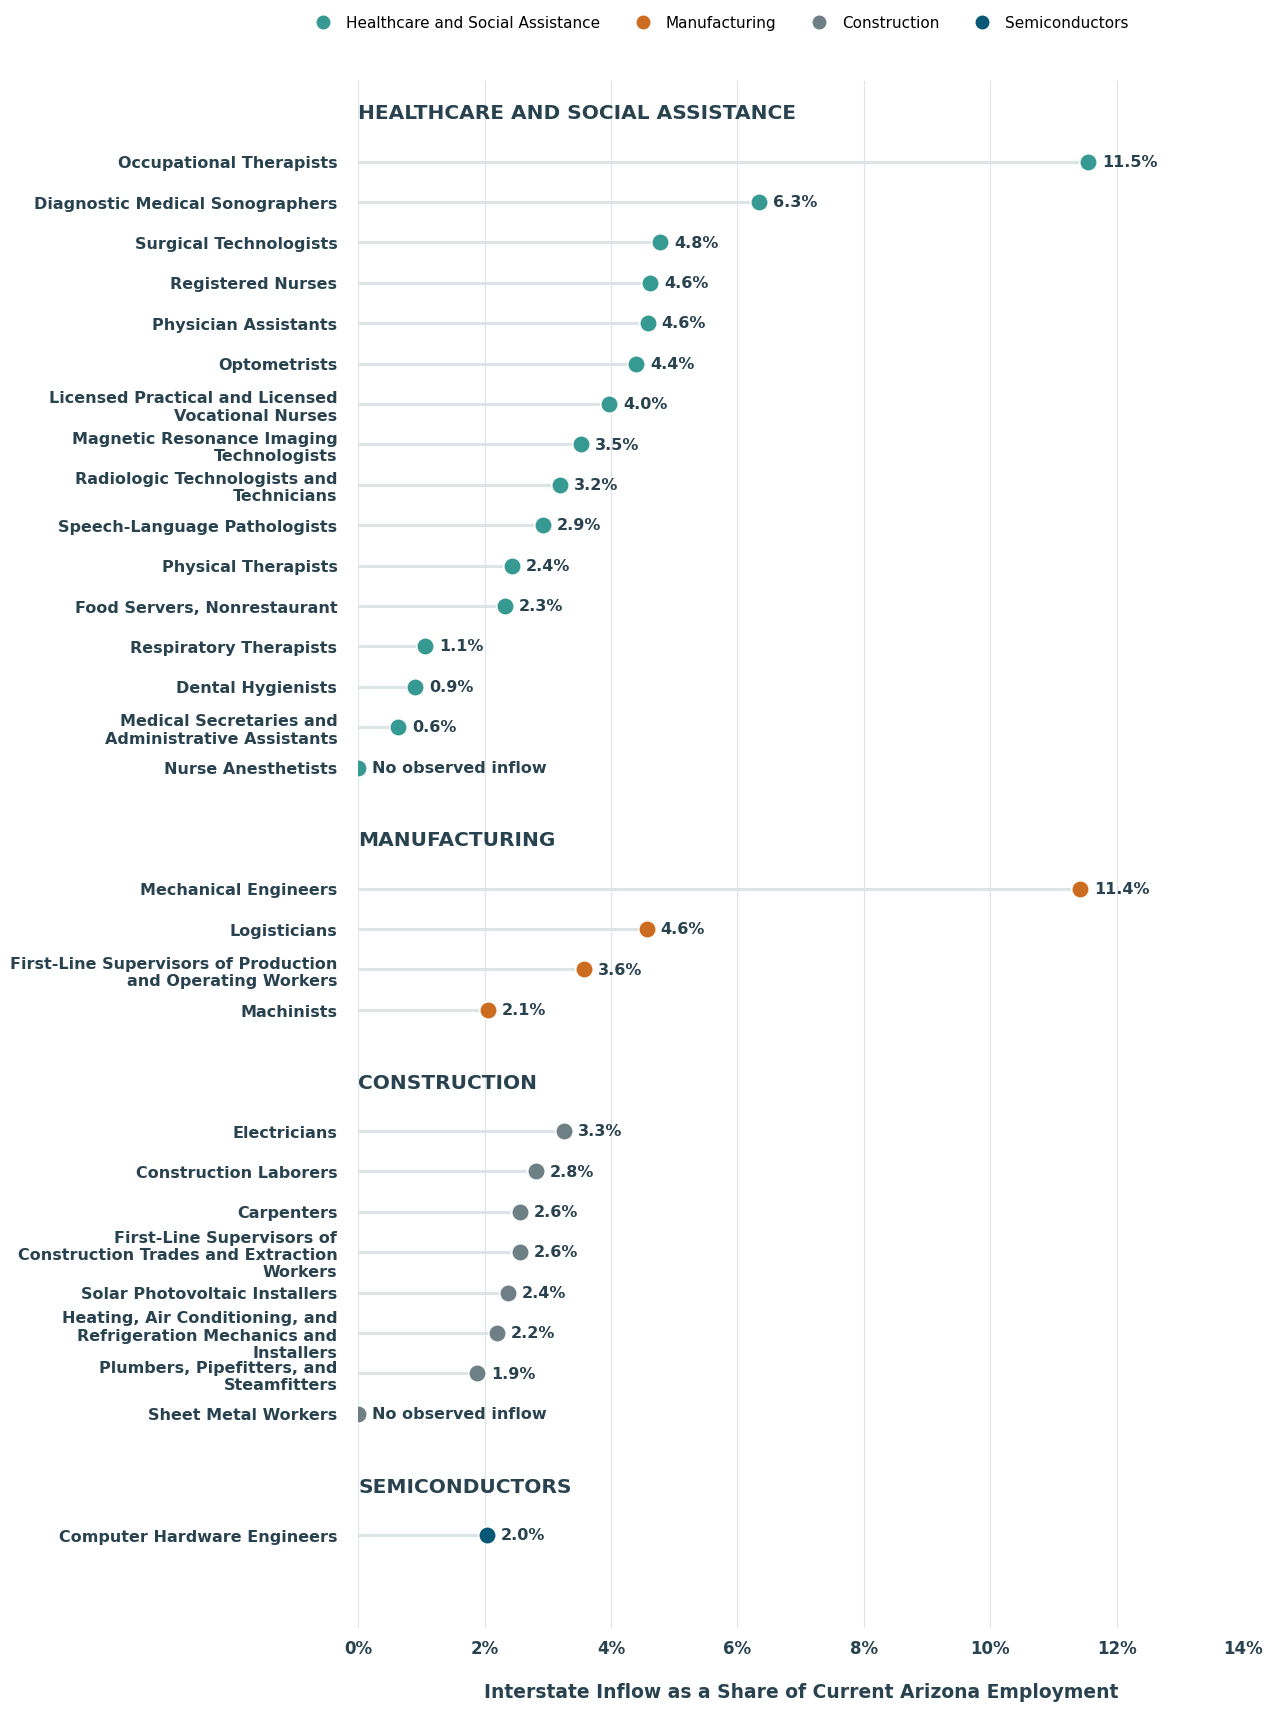

Saved figure: G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Excel Sheets\Arielle Tables\Figure_05_Arizona_Interstate_Talent_Migration.png


In [16]:
# ============================================================
# 6. FIGURE 05 — OCCUPATION-LEVEL INTERSTATE TALENT MIGRATION
# ============================================================

HEALTHCARE = "#369992"
MANUFACTURING = "#CC6C20"
CONSTRUCTION = "#6E7F86"
SEMICONDUCTOR = "#075877"

TEXT = "#29424F"
GRAY = "#75858C"
GRID = "#DDE4E6"
WHITE = "#FFFFFF"

COLORS = {
    "Healthcare and Social Assistance": HEALTHCARE,
    "Manufacturing": MANUFACTURING,
    "Construction": CONSTRUCTION,
    "Semiconductors": SEMICONDUCTOR,
}

# ------------------------------------------------------------
# BUILD CONTINUOUS Y-AXIS WITH SECTOR SPACING
# ------------------------------------------------------------

chart_rows = []
section_headers = {}

y = 0

for sector in SECTOR_ORDER:
    section = (
        chart_data[chart_data["Visual_Sector"].eq(sector)]
        .sort_values("inflow_pct_current_AZ", ascending=False)
        .reset_index(drop=True)
    )

    if section.empty:
        continue

    section_headers[sector] = y
    y += 1.2

    for _, row in section.iterrows():
        temp = row.to_dict()
        temp["y"] = y
        chart_rows.append(temp)
        y += 1

    y += 0.8

chart = pd.DataFrame(chart_rows)

# Dynamic height calculation
FIG_HEIGHT = max(10, len(chart) * 0.52 + 2.5)

fig, ax = plt.subplots(figsize=(15, FIG_HEIGHT))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

# ------------------------------------------------------------
# X RANGE
# ------------------------------------------------------------

max_value = chart["inflow_pct_current_AZ"].max()
XMAX = max(6, np.ceil((max_value + 1.5) / 2) * 2)
ax.set_xlim(0, XMAX)

# ------------------------------------------------------------
# DRAW LOLLIPOPS
# ------------------------------------------------------------

for _, row in chart.iterrows():
    value = row["inflow_pct_current_AZ"]
    sector = str(row["Visual_Sector"])
    color = COLORS[sector]

    # Guideline
    ax.hlines(
        y=row["y"],
        xmin=0,
        xmax=value,
        color=GRID,
        linewidth=2.2,
        zorder=1,
    )

    # All points are now exact matches (filled markers)
    ax.scatter(
        value,
        row["y"],
        s=160,
        facecolor=color,
        edgecolor=WHITE,
        linewidth=1.2,
        zorder=3,
    )

    value_label = (
        "No observed inflow" if row["inflow_sample_n"] == 0 else f"{value:.1f}%"
    )

    ax.annotate(
        value_label,
        xy=(value, row["y"]),
        xytext=(10, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=11.5,
        fontweight="bold",
        color=TEXT,
    )

# ------------------------------------------------------------
# OCCUPATION LABELS
# ------------------------------------------------------------

ax.set_yticks(chart["y"])
ax.set_yticklabels(chart["Label"], fontsize=11.5, fontweight="bold", color=TEXT)
ax.tick_params(axis="y", length=0, pad=15)

# ------------------------------------------------------------
# SECTION HEADERS
# ------------------------------------------------------------

for sector, header_y in section_headers.items():
    ax.text(
        0,
        header_y,
        sector.upper(),
        fontsize=14.5,
        fontweight="bold",
        color=TEXT,
        ha="left",
        va="center",
    )

# ------------------------------------------------------------
# AXES & FORMATTING
# ------------------------------------------------------------

ax.set_ylim(y + 0.5, -0.8)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.tick_params(axis="x", labelsize=12, length=0, pad=8, colors=TEXT)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

ax.set_xlabel(
    "Interstate Inflow as a Share of Current Arizona Employment",
    fontsize=13.5,
    fontweight="bold",
    color=TEXT,
    labelpad=18,
)

ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.grid(axis="y", visible=False)

for spine in ax.spines.values():
    spine.set_visible(False)

# ------------------------------------------------------------
# LEGEND (Cleaner: only active sectors)
# ------------------------------------------------------------

legend_items = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=COLORS[sector],
        markeredgecolor=COLORS[sector],
        markersize=9,
        label=sector,
    )
    for sector in SECTOR_ORDER
    if sector in section_headers
]

fig.legend(
    handles=legend_items,
    loc="upper center",
    bbox_to_anchor=(0.58, 0.995),
    frameon=False,
    ncol=len(legend_items),
    fontsize=11,
    columnspacing=1.8,
    handletextpad=0.5,
)

plt.subplots_adjust(left=0.34, right=0.93, top=0.95, bottom=0.07)

# Save
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight", facecolor=WHITE)
plt.show()

print("Saved figure:", OUTPUT_PNG)

## 7. Export supporting data and QA

The Excel workbook contains:

- **Chart Data** — exact rows displayed in the figure
- **Detailed SOC Results** — detailed occupation-level estimates before shared ACS groups are collapsed
- **SOC-OCCSOC Mapping** — exact/aggregated/no-match mapping information
- **No Match** — selected occupations that could not be represented in ACS
- **Sector Counts** — selected 5-star occupation counts used for QA

This keeps the published figure traceable back to both the current master occupation list and the ACS migration calculation.


In [17]:
# ============================================================
# 7. EXPORT
# ============================================================

sector_count_table = (
    selected
    .groupby(
        "Visual_Sector",
        as_index=False
    )
    .agg(
        selected_5_star_occupations=(
            "SOC_Code",
            "nunique"
        )
    )
)

with pd.ExcelWriter(
    OUTPUT_EXCEL,
    engine="openpyxl"
) as writer:

    chart_data.to_excel(
        writer,
        sheet_name="Chart Data",
        index=False
    )

    final.to_excel(
        writer,
        sheet_name="Detailed SOC Results",
        index=False
    )

    selected.to_excel(
        writer,
        sheet_name="SOC-OCCSOC Mapping",
        index=False
    )

    no_match.to_excel(
        writer,
        sheet_name="No Match",
        index=False
    )

    sector_count_table.to_excel(
        writer,
        sheet_name="Sector Counts",
        index=False
    )

    for worksheet in writer.book.worksheets:

        worksheet.freeze_panes = "A2"

        worksheet.auto_filter.ref = (
            worksheet.dimensions
        )

        worksheet.sheet_view.showGridLines = False


print(
    "Saved workbook:",
    OUTPUT_EXCEL
)

print(
    "\nMatch status:"
)

print(
    selected[
        "Match_Status"
    ].value_counts()
)

print(
    "\nChart rows by sector:"
)

print(
    chart_data[
        "Visual_Sector"
    ].value_counts(
        sort=False
    )
)


Saved workbook: G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Excel Sheets\Arielle Tables\Figure_05_Arizona_Interstate_Talent_Migration.xlsx

Match status:
Match_Status
EXACT         29
AGGREGATED    11
NO MATCH       5
Name: count, dtype: int64

Chart rows by sector:
Visual_Sector
Healthcare and Social Assistance    16
Manufacturing                        4
Construction                         8
Semiconductors                       1
Name: count, dtype: int64
